In [18]:
# 导入库
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

sns.set_style('darkgrid')             # 设置 Seaborn 的绘图风格为 darkgrid（深色网格背景）

In [2]:
# 检查本地 data 输入目录
import os

for dirname, _, filenames in os.walk("data"):
    for filename in filenames:
        print(os.path.join(dirname, filename))


data\dataset-features-categories.csv
data\drebin-215-dataset-5560malware-9476-benign.csv
data\.ipynb_checkpoints\drebin-215-dataset-5560malware-9476-benign-checkpoint.csv


In [3]:
# 配置输入和输出路径
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "data"

DATA_PATH = DATASET_ROOT / "drebin-215-dataset-5560malware-9476-benign.csv"
FEATURE_CATEGORY_PATH = DATASET_ROOT / "dataset-features-categories.csv"

# 如果数据集文件夹发生变化，则先在项目目录中按文件名自动查找 CSV 文件
if not DATA_PATH.exists():
    matches = list(PROJECT_ROOT.rglob("drebin-215-dataset-5560malware-9476-benign.csv"))
    if len(matches) == 0:
        raise FileNotFoundError(f"在项目目录中找不到 drebin CSV 文件：{PROJECT_ROOT}")
    DATA_PATH = matches[0]

if not FEATURE_CATEGORY_PATH.exists():
    matches = list(PROJECT_ROOT.rglob("dataset-features-categories.csv"))
    FEATURE_CATEGORY_PATH = matches[0] if matches else None

OUT_DIR = PROJECT_ROOT / "outputs" / "baseline_v1" # 保存运行结果的位置
MODEL_DIR = PROJECT_ROOT / "models" # 保存模型和特征文件的位置

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42 # 固定随机种子
TEST_SIZE = 0.2 # 测试集比例
LABEL_COL = "class" # 标签列

print("项目根目录 =", PROJECT_ROOT)
print("数据路径 =", DATA_PATH)
print("特征类别路径 =", FEATURE_CATEGORY_PATH)
print("输出目录 =", OUT_DIR)
print("模型目录 =", MODEL_DIR)


项目根目录 = D:\codes\python\jupyter_notebook\终端安全大作业
数据路径 = D:\codes\python\jupyter_notebook\终端安全大作业\data\drebin-215-dataset-5560malware-9476-benign.csv
特征类别路径 = D:\codes\python\jupyter_notebook\终端安全大作业\data\dataset-features-categories.csv
输出目录 = D:\codes\python\jupyter_notebook\终端安全大作业\outputs\baseline_v1
模型目录 = D:\codes\python\jupyter_notebook\终端安全大作业\models


In [4]:
# 加载数据集并检查
df = pd.read_csv(DATA_PATH, low_memory=False)

print("数据形状：", df.shape)
print("列名：", df.columns.tolist()[:10], "...", df.columns.tolist()[-5:])
print("标签计数：")
print(df[LABEL_COL].value_counts())

df.head()

数据形状： (15036, 216)
列名： ['transact', 'onServiceConnected', 'bindService', 'attachInterface', 'ServiceConnection', 'android.os.Binder', 'SEND_SMS', 'Ljava.lang.Class.getCanonicalName', 'Ljava.lang.Class.getMethods', 'Ljava.lang.Class.cast'] ... ['ACCESS_FINE_LOCATION', 'SET_WALLPAPER_HINTS', 'SET_PREFERRED_APPLICATIONS', 'WRITE_SECURE_SETTINGS', 'class']
标签计数：
class
B    9476
S    5560
Name: count, dtype: int64


,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S


In [5]:
# 数据预处理
def map_label(x):
    x = str(x).strip().upper()
    if x in ["B", "BENIGN", "0", "0.0"]:
        return 0
    if x in ["S", "MALWARE", "1", "1.0"]:
        return 1
    raise ValueError(f"未知标签：{x}")

y = df[LABEL_COL].apply(map_label).astype(int)
X = df.drop(columns=[LABEL_COL]).copy()

question_mark_count = int((X.astype(str) == "?").sum().sum())
print("问号缺失值数量：", question_mark_count)

X = X.replace("?", np.nan)
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0)
X = X.astype(np.float32)

print("X 形状：", X.shape)
print("y 计数：")
print(y.value_counts())

问号缺失值数量： 5
X 形状： (15036, 215)
y 计数：
class
0    9476
1    5560
Name: count, dtype: int64


In [6]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("训练集：", X_train.shape)
print("测试集：", X_test.shape)
print("训练集标签计数：")
print(y_train.value_counts())
print("测试集标签计数：")
print(y_test.value_counts())

训练集： (12028, 215)
测试集： (3008, 215)
训练集标签计数：
class
0    7580
1    4448
Name: count, dtype: int64
测试集标签计数：
class
0    1896
1    1112
Name: count, dtype: int64


In [7]:
# 定义 5 个模型
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE,
            solver="liblinear"
        ))
    ]),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LinearSVC(
            random_state=RANDOM_STATE,
            max_iter=10000
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ])
}

In [8]:
# 定义指标计算函数
#给roc准备分数
def get_score_for_roc_auc(model, X_test):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_test)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_test)
    return model.predict(X_test)


def compute_metrics(model_name, model, X_test, y_test, train_time_sec):
    start = time.perf_counter()
    y_pred = model.predict(X_test)
    inference_time_sec = time.perf_counter() - start

    y_score = get_score_for_roc_auc(model, X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    return {
        "model_name": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall_malware": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "fpr": fpr,
        "fnr": fnr,
        "training_time_sec": train_time_sec,
        "inference_time_ms_per_sample": inference_time_sec / len(X_test) * 1000,
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
    }

In [9]:
# 训练所有模型
results = []
trained_models = {}

for model_name, model in models.items():
    print(f"正在训练 {model_name}...")

    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time_sec = time.perf_counter() - start

    metrics = compute_metrics(
        model_name,
        model,
        X_test,
        y_test,
        train_time_sec
    )

    results.append(metrics)
    trained_models[model_name] = model

    print(
        f"{model_name}: "
        f"F1={metrics['f1']:.4f}, "
        f"恶意样本召回率={metrics['recall_malware']:.4f}, "
        f"ROC-AUC={metrics['roc_auc']:.4f}, "
        f"FPR={metrics['fpr']:.4f}"
    )

正在训练 Logistic Regression...
Logistic Regression: F1=0.9707, 恶意样本召回率=0.9676, ROC-AUC=0.9962, FPR=0.0153
正在训练 Linear SVM...
Linear SVM: F1=0.9716, 恶意样本召回率=0.9685, ROC-AUC=0.9958, FPR=0.0148
正在训练 Random Forest...
Random Forest: F1=0.9837, 恶意样本召回率=0.9766, ROC-AUC=0.9989, FPR=0.0053
正在训练 Decision Tree...
Decision Tree: F1=0.9690, 恶意样本召回率=0.9703, ROC-AUC=0.9759, FPR=0.0190
正在训练 KNN...
KNN: F1=0.9747, 恶意样本召回率=0.9685, ROC-AUC=0.9961, FPR=0.0111


In [10]:
# 生成结果表并进行统计
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(
    by=["f1", "recall_malware", "fpr"],
    ascending=[False, False, True]
).reset_index(drop=True)

result_df

,model_name,accuracy,precision,recall_malware,f1,roc_auc,fpr,fnr,training_time_sec,inference_time_ms_per_sample,TP,TN,FP,FN
0,Random Forest,0.988032,0.990876,0.976619,0.983696,0.998883,0.005274,0.023381,1.038296,0.048069,1086,1886,10,26
1,KNN,0.981383,0.980874,0.968525,0.974661,0.996088,0.011076,0.031475,0.059676,1.026347,1077,1875,21,35
2,Linear SVM,0.979056,0.974661,0.968525,0.971583,0.995785,0.014768,0.031475,0.197003,0.003392,1077,1868,28,35
3,Logistic Regression,0.978391,0.973756,0.967626,0.970681,0.996166,0.015295,0.032374,0.429948,0.003197,1076,1867,29,36
4,Decision Tree,0.977061,0.967713,0.970324,0.969017,0.975853,0.018987,0.029676,0.258224,0.001526,1079,1860,36,33


In [11]:
# 保存为 CSV 文件
csv_path = OUT_DIR / "baseline_result_v1.csv"
result_df.to_csv(csv_path, index=False)

print("已保存：", csv_path)

已保存： D:\codes\python\jupyter_notebook\终端安全大作业\outputs\baseline_v1\baseline_result_v1.csv


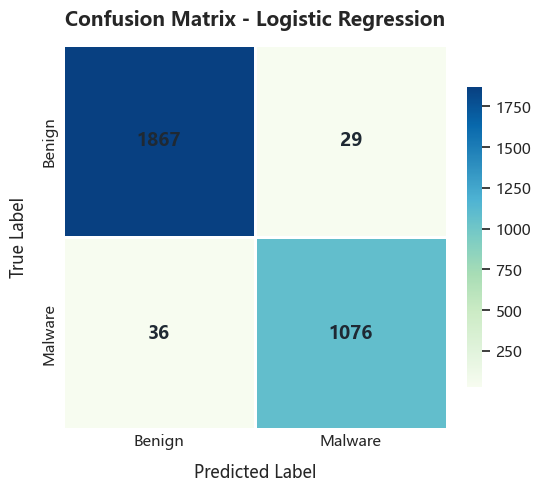

Saved: D:\codes\python\jupyter_notebook\终端安全大作业\outputs\baseline_v1\confusion_matrix_logistic_regression.png


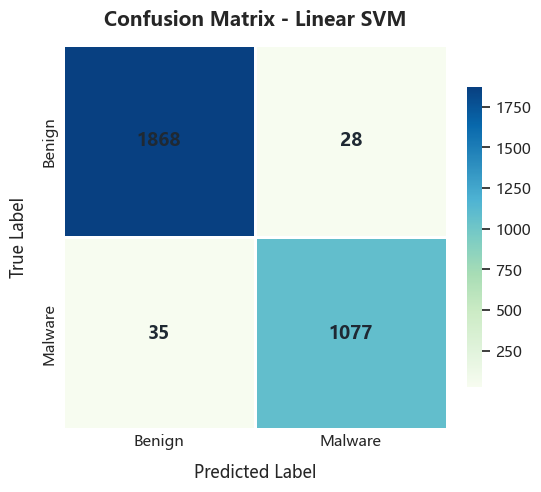

Saved: D:\codes\python\jupyter_notebook\终端安全大作业\outputs\baseline_v1\confusion_matrix_linear_svm.png


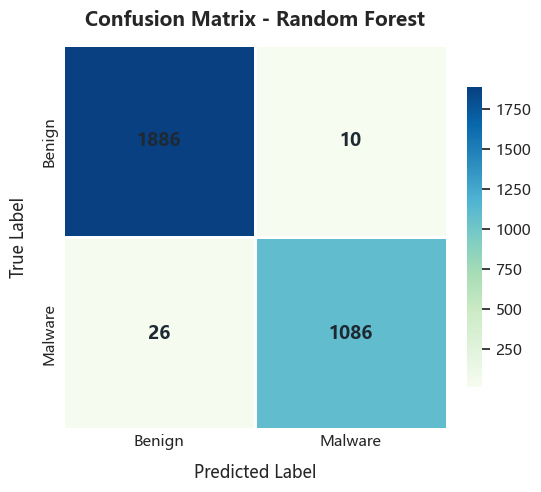

Saved: D:\codes\python\jupyter_notebook\终端安全大作业\outputs\baseline_v1\confusion_matrix_random_forest.png


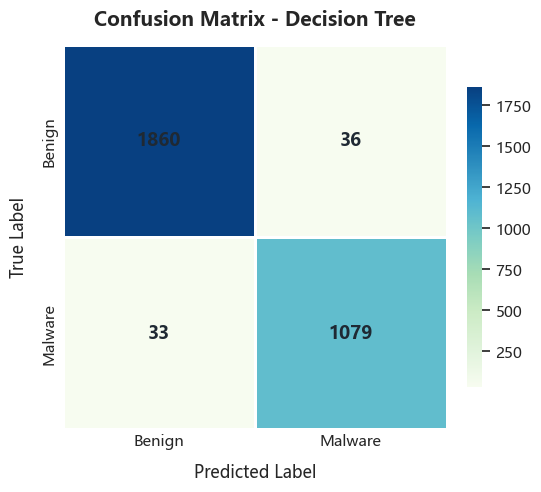

Saved: D:\codes\python\jupyter_notebook\终端安全大作业\outputs\baseline_v1\confusion_matrix_decision_tree.png


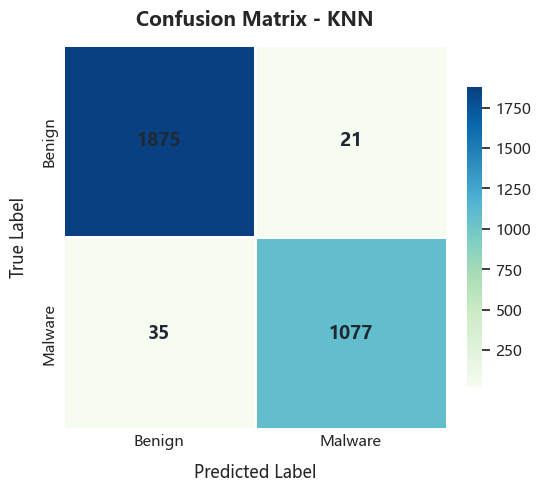

Saved: D:\codes\python\jupyter_notebook\终端安全大作业\outputs\baseline_v1\confusion_matrix_knn.png


In [21]:
# Plot confusion matrices
# TN: true Benign, predicted Benign     FP: true Benign, predicted Malware
# FN: true Malware, predicted Benign    TP: true Malware, predicted Malware
try:
    import seaborn as sns
except ImportError:
    sns = None


def save_confusion_matrix(model_name, model):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    class_names = ["Benign", "Malware"]

    fig, ax = plt.subplots(figsize=(6, 5), facecolor="white")
    ax.set_facecolor("white")

    if sns is not None:
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="GnBu",
            linewidths=0.8,
            linecolor="white",
            square=True,
            cbar=True,
            cbar_kws={"shrink": 0.78, "pad": 0.04},
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={"size": 13, "weight": "bold", "color": "#1f2933"},
            ax=ax,
        )
    else:
        im = ax.imshow(cm, cmap="GnBu", vmin=0)
        fig.colorbar(im, ax=ax, shrink=0.78, pad=0.04)
        ax.set_xticks([0, 1], labels=class_names)
        ax.set_yticks([0, 1], labels=class_names)
        for i in range(2):
            for j in range(2):
                ax.text(
                    j,
                    i,
                    f"{cm[i, j]:d}",
                    ha="center",
                    va="center",
                    fontsize=13,
                    fontweight="bold",
                    color="#1f2933",
                )

    ax.set_title(f"Confusion Matrix - {model_name}", fontsize=14, fontweight="bold", pad=14)
    ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
    ax.set_ylabel("True Label", fontsize=12, labelpad=10)
    ax.tick_params(axis="both", labelsize=11, length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.tight_layout()

    file_name = "confusion_matrix_" + model_name.lower().replace(" ", "_") + ".png"
    path = OUT_DIR / file_name
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("Saved:", path)


for model_name, model in trained_models.items():
    save_confusion_matrix(model_name, model)


In [13]:
# 选择最佳模型并保存为 .pkl 文件
best_model_name = result_df.iloc[0]["model_name"]
best_model = trained_models[best_model_name]

model_package = {
    "model": best_model,
    "model_name": best_model_name,
    "feature_names": list(X.columns),
    "label_mapping": {
        "B": 0,
        "S": 1,
        "benign": 0,
        "malware": 1
    }
}

model_path = MODEL_DIR / f"best_model_{best_model_name.lower().replace(' ', '_')}.pkl"
joblib.dump(model_package, model_path)

print("最佳模型：", best_model_name)
print("已保存：", model_path)

最佳模型： Random Forest
已保存： D:\codes\python\jupyter_notebook\终端安全大作业\models\best_model_random_forest.pkl


In [14]:
# 特征字典
import json

feature_dict_path = MODEL_DIR / "feature_dictionary.json"

with open(feature_dict_path, "w", encoding="utf-8") as f:
    json.dump(
        {"feature_names": list(X.columns)},
        f,
        indent=2,
        ensure_ascii=False
    )

print("已保存：", feature_dict_path)

已保存： D:\codes\python\jupyter_notebook\终端安全大作业\models\feature_dictionary.json


In [15]:
# 输出基线总结
summary_path = OUT_DIR / "baseline_summary.md"

best = result_df.iloc[0]

summary = f"""
# 基线 v1 总结

## 数据集

- 数据集：Drebin-215 Android 恶意软件数据集
- 数据形状：{df.shape[0]} 个样本 x {df.shape[1]} 列
- 特征数量：{X.shape[1]}
- 标签列：{LABEL_COL}
- 良性样本：{(y == 0).sum()}
- 恶意样本：{(y == 1).sum()}
- 训练集大小：{X_train.shape[0]}
- 测试集大小：{X_test.shape[0]}
- 划分方式：80/20，stratify=y，random_state=42

## 模型

已训练模型：

- Logistic Regression
- Linear SVM
- Random Forest
- Decision Tree
- KNN

## 最佳基线模型

最佳模型：{best["model_name"]}

评估指标：

- 准确率：{best["accuracy"]:.6f}
- 精确率：{best["precision"]:.6f}
- 恶意样本召回率：{best["recall_malware"]:.6f}
- F1-score: {best["f1"]:.6f}
- ROC-AUC: {best["roc_auc"]:.6f}
- FPR: {best["fpr"]:.6f}
- FNR: {best["fnr"]:.6f}
- 训练时间：{best["training_time_sec"]:.6f} 秒
- 推理时间：{best["inference_time_ms_per_sample"]:.6f} 毫秒/样本
- TP: {int(best["TP"])}
- TN: {int(best["TN"])}
- FP: {int(best["FP"])}
- FN: {int(best["FN"])}

## 结论

Random Forest 是本次运行中表现最好的基线模型，因为它取得了最高的 F1-score、较高的恶意样本召回率、很低的 FPR，以及较好的 ROC-AUC。

不过，这仍然只是基于 Drebin-215 特征集得到的基线结果，不能作为适用于所有数据集的最终结论。后续可以继续尝试 XGBoost/LightGBM，分析特征重要性，使用多个随机种子或交叉验证重复实验，并在更新的特征集或 static-full 特征集上进一步评估。
"""

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary)

print("已保存：", summary_path)

已保存： D:\codes\python\jupyter_notebook\终端安全大作业\outputs\baseline_v1\baseline_summary.md


In [16]:
# 压缩所有输出文件
import zipfile

zip_path = PROJECT_ROOT / "outputs" / "baseline_week3_4_outputs.zip"
zip_path.parent.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for folder in [OUT_DIR, MODEL_DIR]:
        if folder.exists():
            for file_path in folder.rglob("*"):
                if file_path.is_file() and file_path != zip_path:
                    zf.write(file_path, file_path.relative_to(PROJECT_ROOT))

print("压缩包路径：", zip_path)


压缩包路径： D:\codes\python\jupyter_notebook\终端安全大作业\outputs\baseline_week3_4_outputs.zip
